# TPMS Stress Analysis — Understanding Load & Drive Dynamics

This notebook analyzes stress characteristics across the vehicle fleet:
- Load utilization patterns
- Drive configuration stress (driven_ratio)
- Wear acceleration and behavior
- Vehicle-to-vehicle comparisons
- Stress ranking by category

**Goal:** Understand stress dynamics without computing final RUL score yet.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv(r'E:\TPMS\data\processed\cleaned_configuration_data.csv')
print("Data shape:", df.shape)
print("\nFirst few rows:")
df.head()


Data shape: (4, 23)

First few rows:


,vehicle_id,vehicle_type,axle_configuration,axle_count,wheel_count,gvwr_kg,curb_weight,tire_brand,model,size,...,max_load_single_kg,section_width_mm,overall_diameter_mm,initial_tread,tyre_life,total_wheels,driven_wheels,driven_ratio,load_per_wheel,drive_stress_factor
0,MH14JK7645,TRUCK,4x2,2,6,16200,7500,MRF,SUPERLUG,11.00-22,...,3525,3090,1160,21.5,120000,4,2,0.500000,2175.000000,4350.0
1,RJ21LM7621,Semi-Trailer,6x4,3,10,25000,8500,Michelin,X Line Energy,295/80R22.5,...,3550,298,1044,18.5,165000,6,4,0.666667,2750.000000,4125.0
2,MH47MD4509,Box Van,4x2,2,4,7500,3200,Bridgestone,Duravis R660,225/75R16C,...,1450,225,744,9.0,65000,4,2,0.500000,1075.000000,2150.0
3,MH12XD7689,Pickup,6x2,2,8,3500,2100,Goodyear,Wrangler AT,265/70R17,...,1120,265,804,12.2,55000,6,2,0.333333,233.333333,700.0


In [28]:
# Verify engineered columns are present
print("Column names:")
print(df.columns.tolist())
print("\n" + "="*60)

# Check for key engineered columns
engineered_cols = ['driven_ratio', 'load_per_wheel', 'drive_stress_factor', 'driven_wheels', 'total_wheels']
for col in engineered_cols:
    if col in df.columns:
        print(f"✓ {col}: {df[col].dtype}")
    else:
        print(f"✗ {col}: MISSING")

print("\n" + "="*60)
print("\nBasic statistics for engineered columns:")
print(df[engineered_cols].describe())


Column names:
['vehicle_id', 'vehicle_type', 'axle_configuration', 'axle_count', 'wheel_count', 'gvwr_kg', 'curb_weight', 'tire_brand', 'model', 'size', 'ply_rating', 'max_pressure_psi', 'idel_temp', 'max_load_single_kg', 'section_width_mm', 'overall_diameter_mm', 'initial_tread', 'tyre_life', 'total_wheels', 'driven_wheels', 'driven_ratio', 'load_per_wheel', 'drive_stress_factor']

✓ driven_ratio: float64
✓ load_per_wheel: float64
✓ drive_stress_factor: float64
✓ driven_wheels: int64
✓ total_wheels: int64


Basic statistics for engineered columns:
       driven_ratio  load_per_wheel  drive_stress_factor  driven_wheels  \
count      4.000000        4.000000             4.000000            4.0   
mean       0.500000     1558.333333          2831.250000            2.5   
std        0.136083     1123.919234          1730.772347            1.0   
min        0.333333      233.333333           700.000000            2.0   
25%        0.458333      864.583333          1787.500000            2.

Load Margin Statistics:
count       4.000000
mean      852.916667
std       399.764688
min       375.000000
25%       693.750000
50%       843.333333
75%      1002.500000
max      1350.000000
Name: load_margin, dtype: float64


Load Margin by Vehicle Type:
              Avg Margin  Min Margin  Max Margin  Avg Utilization  \
vehicle_type                                                        
Box Van           375.00      375.00      375.00             0.74   
Pickup            886.67      886.67      886.67             0.21   
Semi-Trailer      800.00      800.00      800.00             0.77   
TRUCK            1350.00     1350.00     1350.00             0.62   

              Max Utilization  
vehicle_type                   
Box Van                  0.74  
Pickup                   0.21  
Semi-Trailer             0.77  
TRUCK                    0.62  


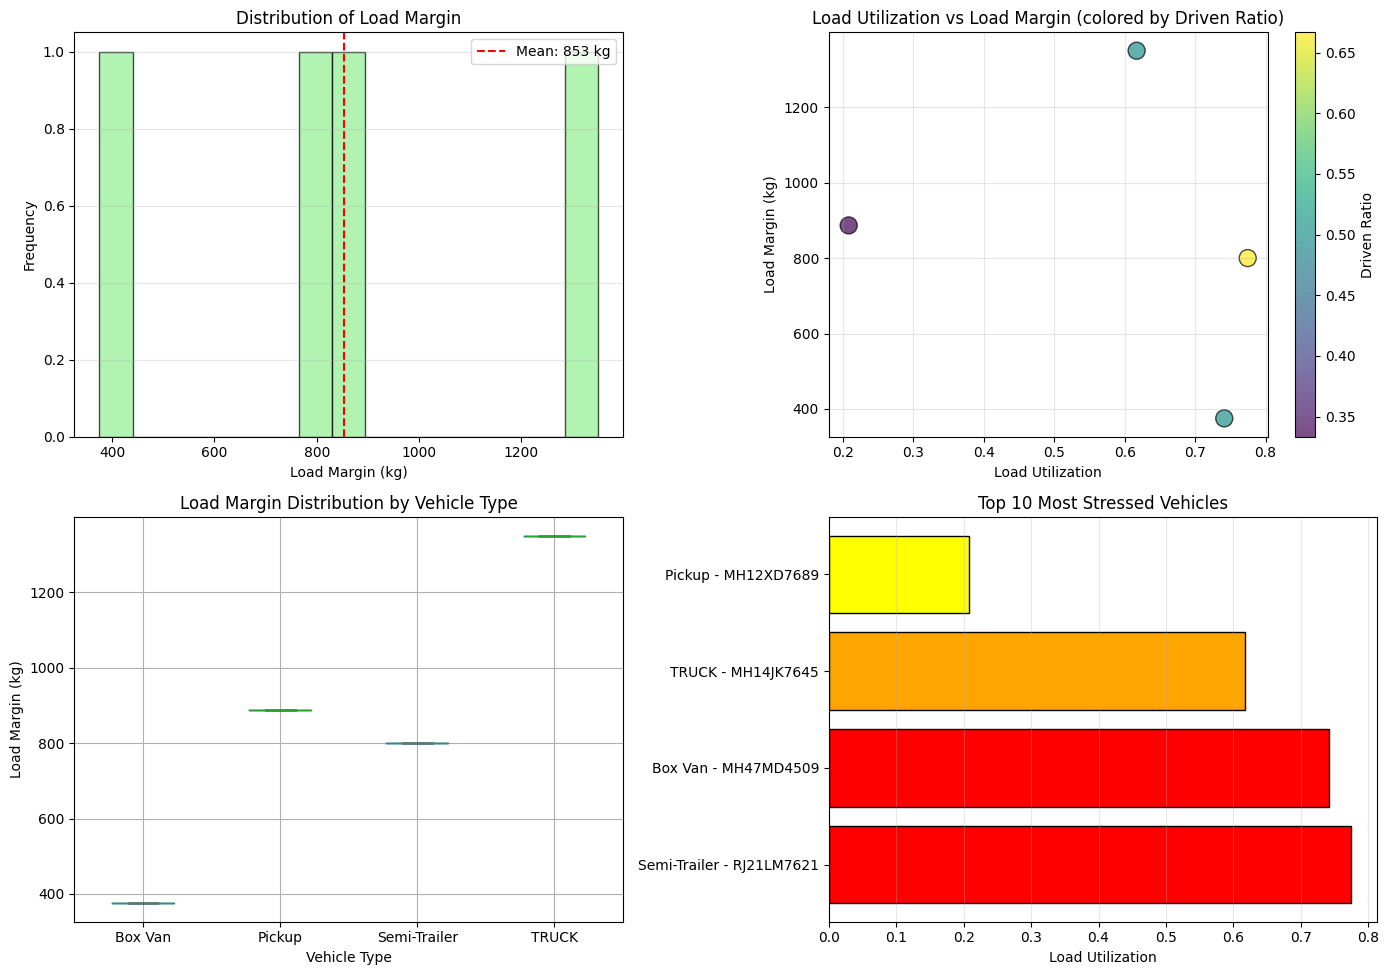



Key Findings:
- Average load margin across fleet: 853 kg
- Vehicles with margin < 500 kg: 1


In [36]:
# Calculate load margin: reserve capacity on each wheel
df['load_margin'] = df['max_load_single_kg'] - df['load_per_wheel']

# Show summary of load margin and utilization
print("Load Margin Statistics:")
print(df['load_margin'].describe())

print("\n" + "="*100)
print("\nLoad Margin by Vehicle Type:")
margin_by_type = df.groupby('vehicle_type').agg({
    'load_margin': ['mean', 'min', 'max'],
    'load_utilization': ['mean', 'max'],
}).round(2)
margin_by_type.columns = ['Avg Margin', 'Min Margin', 'Max Margin', 'Avg Utilization', 'Max Utilization']
print(margin_by_type)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Load margin distribution
axes[0, 0].hist(df['load_margin'], bins=15, edgecolor='black', alpha=0.7, color='lightgreen')
axes[0, 0].axvline(df['load_margin'].mean(), color='red', linestyle='--', label=f'Mean: {df["load_margin"].mean():.0f} kg')
axes[0, 0].set_xlabel('Load Margin (kg)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Load Margin')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Load utilization vs Load margin scatter
scatter = axes[0, 1].scatter(df['load_utilization'], df['load_margin'],
                             c=df['driven_ratio'], cmap='viridis', s=150, alpha=0.7, edgecolors='black')
axes[0, 1].set_xlabel('Load Utilization')
axes[0, 1].set_ylabel('Load Margin (kg)')
axes[0, 1].set_title('Load Utilization vs Load Margin (colored by Driven Ratio)')
axes[0, 1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0, 1], label='Driven Ratio')

# 3. Load margin by vehicle type (box plot)
df.boxplot(column='load_margin', by='vehicle_type', ax=axes[1, 0])
axes[1, 0].set_xlabel('Vehicle Type')
axes[1, 0].set_ylabel('Load Margin (kg)')
axes[1, 0].set_title('Load Margin Distribution by Vehicle Type')
plt.suptitle('')

# 4. Stress ranking bar chart
top_vehicles = df.sort_values('load_utilization', ascending=False).head(10)
# ensure vehicle_category exists for labels
if 'vehicle_category' not in top_vehicles.columns:
    top_vehicles['vehicle_category'] = top_vehicles['vehicle_type'] + ' - ' + top_vehicles['vehicle_id']

colors = ['red' if x > 0.7 else 'orange' if x > 0.5 else 'yellow' for x in top_vehicles['load_utilization']]
axes[1, 1].barh(range(len(top_vehicles)), top_vehicles['load_utilization'], color=colors, edgecolor='black')
axes[1, 1].set_yticks(range(len(top_vehicles)))
axes[1, 1].set_yticklabels(top_vehicles['vehicle_category'])
axes[1, 1].set_xlabel('Load Utilization')
axes[1, 1].set_title('Top 10 Most Stressed Vehicles')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("\nKey Findings:")
print(f"- Average load margin across fleet: {df['load_margin'].mean():.0f} kg")
print(f"- Vehicles with margin < 500 kg: {(df['load_margin'] < 500).sum()}")

## Load Margin Analysis

Load margin measures how much reserve capacity remains on each wheel.
Lower margin = higher risk, closer to maximum load capacity.


In [37]:
# STEP 1 & 2 — Weighted Stress Score (Load Dominates)
# Replace rank-based logic with continuous stress score
# Load utilization weighted at 80% (dominant factor)
# Driven ratio weighted at 20% (supporting factor)

df['stress_score'] = (
    0.8 * df['load_utilization'] +
    0.2 * df['driven_ratio']
)

print("STEP 2: Weighted Stress Score Calculation")
print("="*80)
print(f"Formula: stress_score = 0.8 × load_utilization + 0.2 × driven_ratio")
print(f"\nStress Score Statistics:")
print(df['stress_score'].describe())

print("\n" + "="*80)
print("\nStress Score by Vehicle:")
for idx, row in df.iterrows():
    print(f"{row['vehicle_id']:15} | Load Util: {row['load_utilization']:.3f} | Driven Ratio: {row['driven_ratio']:.3f} | Score: {row['stress_score']:.3f}")


STEP 2: Weighted Stress Score Calculation
Formula: stress_score = 0.8 × load_utilization + 0.2 × driven_ratio

Stress Score Statistics:
count    4.000000
mean     0.568276
std      0.232775
min      0.233333
25%      0.503546
50%      0.643360
75%      0.708090
max      0.753052
Name: stress_score, dtype: float64


Stress Score by Vehicle:
MH14JK7645      | Load Util: 0.617 | Driven Ratio: 0.500 | Score: 0.594
RJ21LM7621      | Load Util: 0.775 | Driven Ratio: 0.667 | Score: 0.753
MH47MD4509      | Load Util: 0.741 | Driven Ratio: 0.500 | Score: 0.693
MH12XD7689      | Load Util: 0.208 | Driven Ratio: 0.333 | Score: 0.233


In [ ]:
# STEP 6 — Save Intelligence Output

# Create enriched output DataFrame
output_cols = ['rank', 'vehicle_category', 'vehicle_id', 'vehicle_type', 'load_per_wheel', 'max_load_single_kg', 
               'load_margin', 'load_margin_kg', 'load_utilization', 'driven_wheels', 'total_wheels', 'driven_ratio',
               'initial_tread_mm', 'tyre_life_km', 'wear_rate_per_1000km', 'stress_score', 'risk_level',
               'recommended_action', 'maintenance_priority', 'priority_rank']

df_output = df_sorted[output_cols].copy()

# Create output directory if it doesn't exist
import os
output_dir = r'E:\TPMS\data\enriched'
os.makedirs(output_dir, exist_ok=True)

# Save to CSV
output_path = os.path.join(output_dir, 'tire_intelligence_v1.csv')
df_output.to_csv(output_path, index=False)

print("STEP 6: Intelligence Output Saved")
print("="*100)
print(f"✓ File saved to: {output_path}")
print(f"✓ Total records: {len(df_output)}")
print(f"✓ Columns: {', '.join(output_cols)}")

print("\n" + "="*100)
print("\nOutput Sample (First 3 rows):")
print(df_output.head(3).to_string(index=False))


STEP 6: Intelligence Output Saved
✓ File saved to: E:\TPMS\data\enriched\tire_intelligence_v1.csv
✓ Total records: 4
✓ Columns: rank, vehicle_category, vehicle_id, vehicle_type, load_per_wheel, max_load_single_kg, load_margin, load_utilization, driven_wheels, total_wheels, driven_ratio, initial_tread_mm, tyre_life_km, wear_rate_per_1000km, stress_score, risk_level


Output Sample (First 3 rows):
 rank          vehicle_category vehicle_id vehicle_type  load_per_wheel  max_load_single_kg  load_margin  load_utilization  driven_wheels  total_wheels  driven_ratio  initial_tread_mm  tyre_life_km  wear_rate_per_1000km  stress_score risk_level
    1 Semi-Trailer - RJ21LM7621 RJ21LM7621 Semi-Trailer          2750.0                3550        800.0          0.774648              4             6      0.666667              18.5      165000.0              0.112121      0.753052       High
    2      Box Van - MH47MD4509 MH47MD4509      Box Van          1075.0                1450        375.0       

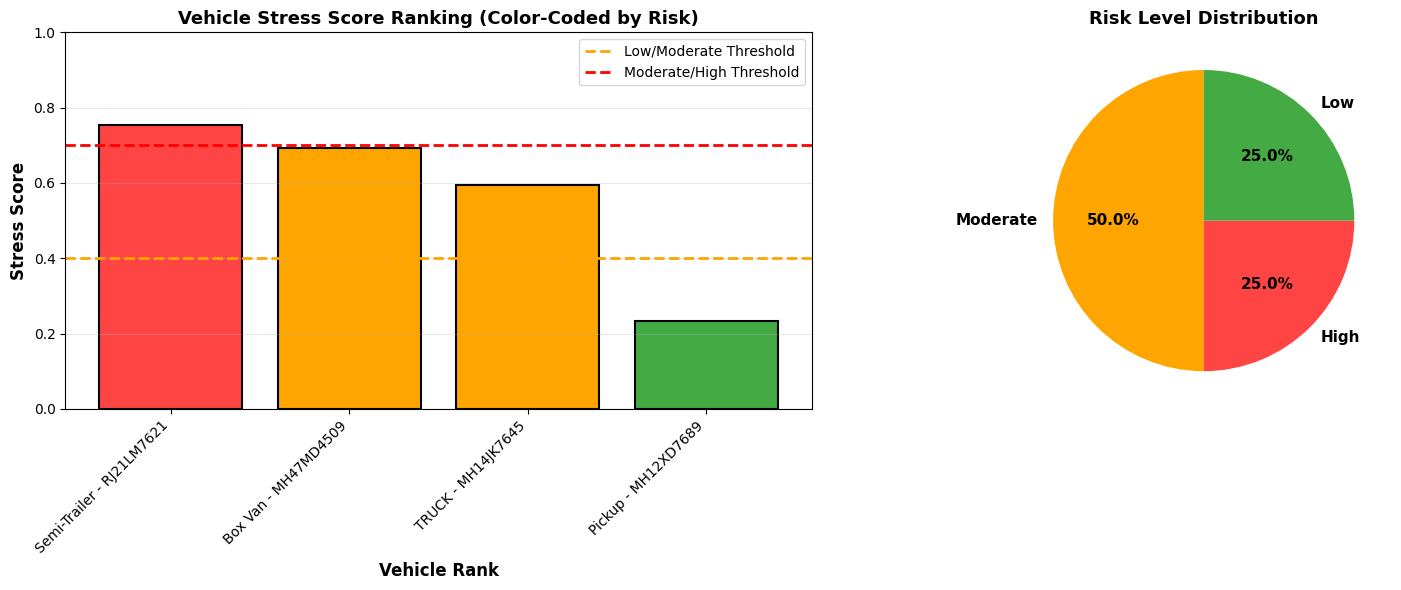

STEP 5: Visualization Complete
→ Bar chart shows stress score hierarchy with risk-based coloring
→ Pie chart shows fleet risk distribution


In [40]:
# STEP 5 — Visualization (Stress Score with Risk Color Coding)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Create color map: High=Red, Moderate=Orange, Low=Green
color_map = {'High': '#FF4444', 'Moderate': '#FFA500', 'Low': '#44AA44'}
colors = [color_map[risk] for risk in df_sorted['risk_level']]

# Plot 1: Bar chart with risk-based colors
axes[0].bar(range(len(df_sorted)), df_sorted['stress_score'], color=colors, edgecolor='black', linewidth=1.5)
axes[0].axhline(y=0.40, color='orange', linestyle='--', linewidth=2, label='Low/Moderate Threshold')
axes[0].axhline(y=0.70, color='red', linestyle='--', linewidth=2, label='Moderate/High Threshold')
axes[0].set_xlabel('Vehicle Rank', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Stress Score', fontsize=12, fontweight='bold')
axes[0].set_title('Vehicle Stress Score Ranking (Color-Coded by Risk)', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(df_sorted)))
axes[0].set_xticklabels(df_sorted['vehicle_category'], rotation=45, ha='right')
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(fontsize=10)

# Plot 2: Risk distribution pie chart
risk_counts = df['risk_level'].value_counts()
colors_pie = [color_map.get(risk, '#999999') for risk in risk_counts.index]
wedges, texts, autotexts = axes[1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
                                         colors=colors_pie, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Risk Level Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("STEP 5: Visualization Complete")
print("→ Bar chart shows stress score hierarchy with risk-based coloring")
print("→ Pie chart shows fleet risk distribution")


In [ ]:
# STEP 4 — Sort by Stress Score & Display

# add combined category field for display
if 'vehicle_category' not in df.columns:
    df['vehicle_category'] = df['vehicle_type'] + ' - ' + df['vehicle_id']

# sort by stress
df_sorted = df.sort_values(by='stress_score', ascending=False).reset_index(drop=True)
df_sorted['rank'] = range(1, len(df_sorted) + 1)

print("STEP 4: Vehicles Ranked by Stress Score (Highest First)")
print("="*100)

result_display = df_sorted[['rank', 'vehicle_category', 'load_utilization', 
                             'driven_ratio', 'stress_score', 'risk_level', 'load_margin',
                             'maintenance_priority', 'priority_rank']].copy()

print(result_display.to_string(index=False))

print("\n" + "="*100)
print("\nRank Summary:")
print(f"  🔴 HIGH RISK (score ≥ 0.80)    : {(df_sorted['risk_level'] == 'High').sum()} vehicles")
print(f"  🟡 MODERATE RISK (0.40-0.70)   : {(df_sorted['risk_level'] == 'Moderate').sum()} vehicles")
print(f"  🚨 Highest Priority Vehicle: {df_sorted.sort_values('maintenance_priority', ascending=False).iloc[0]['vehicle_category']} - Priority: {df_sorted['maintenance_priority'].max():.3f}")
print(f"\n  Highest Risk Vehicle: {df_sorted.iloc[0]['vehicle_category']} ({df_sorted.iloc[0]['risk_level']}) - Score: {df_sorted.iloc[0]['stress_score']:.3f}")
print(f"  Lowest Risk Vehicle:  {df_sorted.iloc[-1]['vehicle_category']} ({df_sorted.iloc[-1]['risk_level']}) - Score: {df_sorted.iloc[-1]['stress_score']:.3f}")



STEP 4: Vehicles Ranked by Stress Score (Highest First)
 rank          vehicle_category  load_utilization  driven_ratio  stress_score risk_level  load_margin
    1 Semi-Trailer - RJ21LM7621          0.774648      0.666667      0.753052       High   800.000000
    2      Box Van - MH47MD4509          0.741379      0.500000      0.693103   Moderate   375.000000
    3        TRUCK - MH14JK7645          0.617021      0.500000      0.593617   Moderate  1350.000000
    4       Pickup - MH12XD7689          0.208333      0.333333      0.233333        Low   886.666667


Rank Summary:
  🔴 HIGH RISK (score ≥ 0.80)    : 1 vehicles
  🟡 MODERATE RISK (0.40-0.70)   : 2 vehicles
  🟢 LOW RISK (score < 0.30)     : 1 vehicles

  Highest Risk Vehicle: Semi-Trailer - RJ21LM7621 (High) - Score: 0.753
  Lowest Risk Vehicle:  Pickup - MH12XD7689 (Low) - Score: 0.233


In [ ]:
# STEP 4.1 — Maintenance Priority Visualization
plt.figure(figsize=(8,5))
plt.bar(df['vehicle_id'], df['maintenance_priority'], color='purple', edgecolor='black')
plt.title("Maintenance Priority Index")
plt.ylabel("Priority")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [38]:
# STEP 3 — Risk Classification
# Define risk levels based on stress score thresholds

def classify_risk(score):
    """
    Classify risk level based on continuous stress score.
    Score range: 0 to 1
    """
    if score < 0.40:
        return "Low"
    elif score < 0.70:
        return "Moderate"
    else:
        return "High"

df['risk_level'] = df['stress_score'].apply(classify_risk)

print("STEP 3: Risk Classification")
print("="*80)
print("\nRisk Level Thresholds:")
print("  • Low Risk:       stress_score < 0.40")
print("  • Moderate Risk:  0.40 ≤ stress_score < 0.70")
print("  • High Risk:      stress_score ≥ 0.70")

print("\n" + "="*80)
print("\nRisk Level Distribution:")
risk_counts = df['risk_level'].value_counts()
for risk, count in risk_counts.items():
    percentage = (count / len(df)) * 100
    print(f"  {risk:10} : {count} vehicles ({percentage:.1f}%)")


STEP 3: Risk Classification

Risk Level Thresholds:
  • Low Risk:       stress_score < 0.40
  • Moderate Risk:  0.40 ≤ stress_score < 0.70
  • High Risk:      stress_score ≥ 0.70


Risk Level Distribution:
  Moderate   : 2 vehicles (50.0%)
  High       : 1 vehicles (25.0%)
  Low        : 1 vehicles (25.0%)


In [ ]:
# STEP 3.1 — Engineering Enhancements
# absolute safety buffer and operational guidance

# load margin in kg (duplicate of earlier column but kept for clarity)
df["load_margin_kg"] = df["max_load_single_kg"] - df["load_per_wheel"]

# add maintenance recommendation based on risk level
def recommend_action(risk):
    if risk == "High":
        return "Immediate inspection required"
    elif risk == "Moderate":
        return "Schedule maintenance check"
    else:
        return "Normal monitoring"

df["recommended_action"] = df["risk_level"].apply(recommend_action)

# priority index penalises low margin vehicles
# (add 1 to denominator to avoid divide-by-zero)
df["maintenance_priority"] = (
    df["stress_score"] * (1 / (df["load_margin_kg"] + 1))
)
# ranking for convenience
df["priority_rank"] = df["maintenance_priority"].rank(ascending=False)

print("Engineering metrics added:")
print(df[["load_margin_kg","recommended_action","maintenance_priority","priority_rank"]].head())


## Summary: Stress Dynamics Understanding

**Key Findings:**
1. **Load Utilization**: Identifies how heavily wheels are loaded relative to capacity
2. **Driven Ratio**: Lower ratios (fewer driven wheels) concentrate stress on fewer wheels
3. **Wear Behavior**: Shows correlation between stress metrics and actual tyre degradation
4. **Vehicle Comparison**: Profiles reveal distinct stress patterns across vehicle types
5. **Composite Ranking**: Combines multiple stress dimensions into priority ranking

**Next Steps:**
- Use these stress insights to inform RUL score weighting
- Identify high-stress vehicle maintenance priorities
- Correlate stress rankings with failure history (when available)


## 5. Stress Ranking by Category

Rank vehicles within stress dimensions independently to understand multi-dimensional stress.


Top 10 Most Stressed Vehicle Categories (by load utilization):
            vehicle_category  vehicle_type  load_utilization  driven_ratio  load_per_wheel  wear_rate_per_1000km  tyre_life_km  initial_tread_mm
1  Semi-Trailer - RJ21LM7621  Semi-Trailer          0.774648      0.666667     2750.000000              0.112121      165000.0              18.5
2       Box Van - MH47MD4509       Box Van          0.741379      0.500000     1075.000000              0.138462       65000.0               9.0
0         TRUCK - MH14JK7645         TRUCK          0.617021      0.500000     2175.000000              0.179167      120000.0              21.5
3        Pickup - MH12XD7689        Pickup          0.208333      0.333333      233.333333              0.221818       55000.0              12.2


Bottom 10 Least Stressed Vehicle Categories:
            vehicle_category  vehicle_type  load_utilization  driven_ratio  load_per_wheel  wear_rate_per_1000km  tyre_life_km  initial_tread_mm
1  Semi-Trailer - RJ

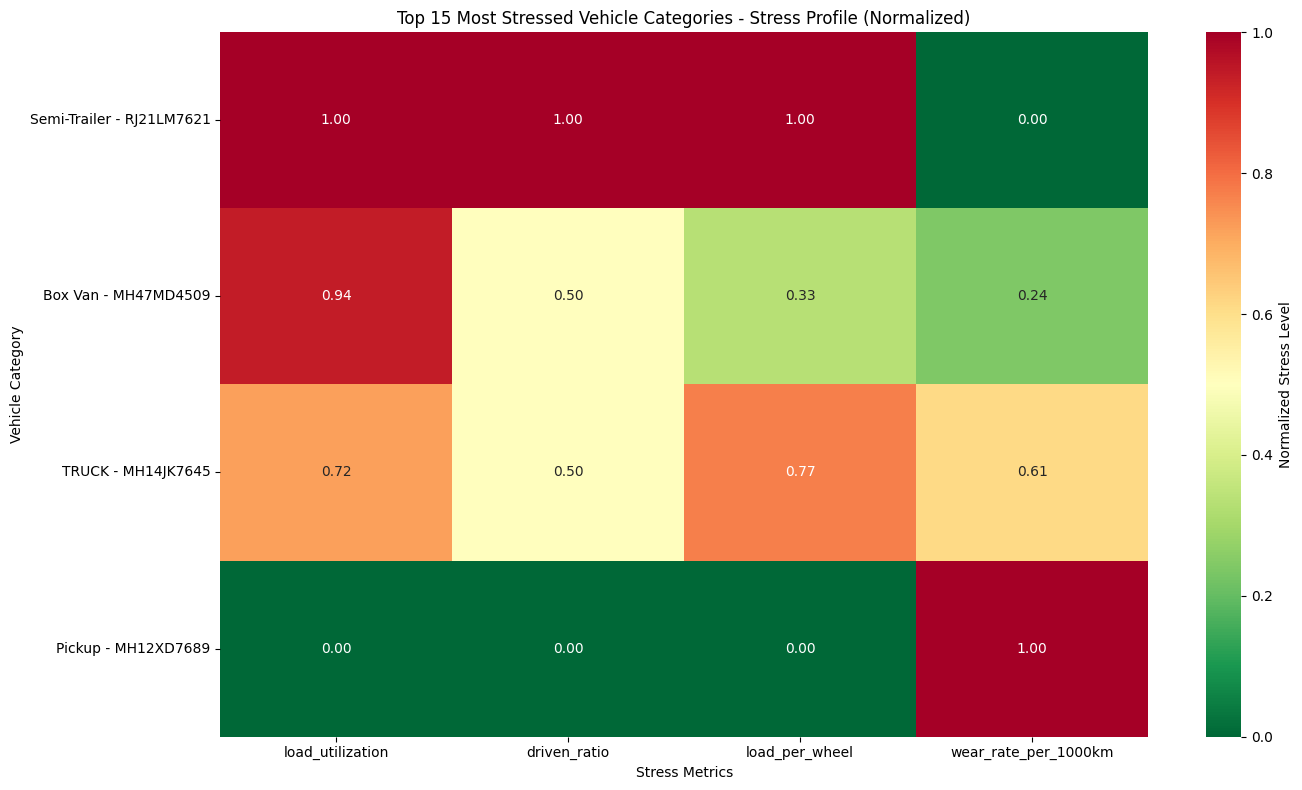

In [41]:
# Create a stress profile for each vehicle
stress_profile = df[['vehicle_category', 'vehicle_type', 'load_utilization', 'driven_ratio', 
                      'load_per_wheel', 'wear_rate_per_1000km', 'tyre_life_km', 'initial_tread_mm']].copy()

# Sort by load utilization (high to low = stress ranking)
stress_sorted = stress_profile.sort_values('load_utilization', ascending=False)

print("Top 10 Most Stressed Vehicle Categories (by load utilization):")
print(stress_sorted.head(10).to_string())

print("\n" + "="*60)
print("\nBottom 10 Least Stressed Vehicle Categories:")
print(stress_sorted.tail(10).to_string())

# Visualization: Stress Profile Heatmap
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for heatmap (normalized)
# use category as index for easier interpretation
heatmap_data = stress_profile.set_index('vehicle_category')[['load_utilization', 'driven_ratio', 'load_per_wheel', 'wear_rate_per_1000km']]
heatmap_data_top = heatmap_data.loc[stress_sorted.head(15)['vehicle_category']]

# Normalize each column to 0-1 range for better visualization
normalized_data = (heatmap_data_top - heatmap_data_top.min()) / (heatmap_data_top.max() - heatmap_data_top.min())

sns.heatmap(normalized_data, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=ax, cbar_kws={'label': 'Normalized Stress Level'})
ax.set_title('Top 15 Most Stressed Vehicle Categories - Stress Profile (Normalized)')
ax.set_xlabel('Stress Metrics')
ax.set_ylabel('Vehicle Category')
plt.tight_layout()
plt.show()


## 4. Vehicle Comparison - Stress Profile Matrix

Compare vehicles across multiple stress dimensions.


Wear Behavior Statistics:
       initial_tread_mm   tyre_life_km  wear_rate_per_1000km
count          4.000000       4.000000              4.000000
mean          15.300000  101250.000000              0.162892
std            5.714893   51214.418543              0.047999
min            9.000000   55000.000000              0.112121
25%           11.400000   62500.000000              0.131876
50%           15.350000   92500.000000              0.158814
75%           19.250000  131250.000000              0.189830
max           21.500000  165000.000000              0.221818


Wear Metrics by Vehicle Type:
             initial_tread_mm             tyre_life_km                      \
                         mean   min   max         mean       min       max   
vehicle_type                                                                 
Box Van                   9.0   9.0   9.0      65000.0   65000.0   65000.0   
Pickup                   12.2  12.2  12.2      55000.0   55000.0   55000.0   
Sem

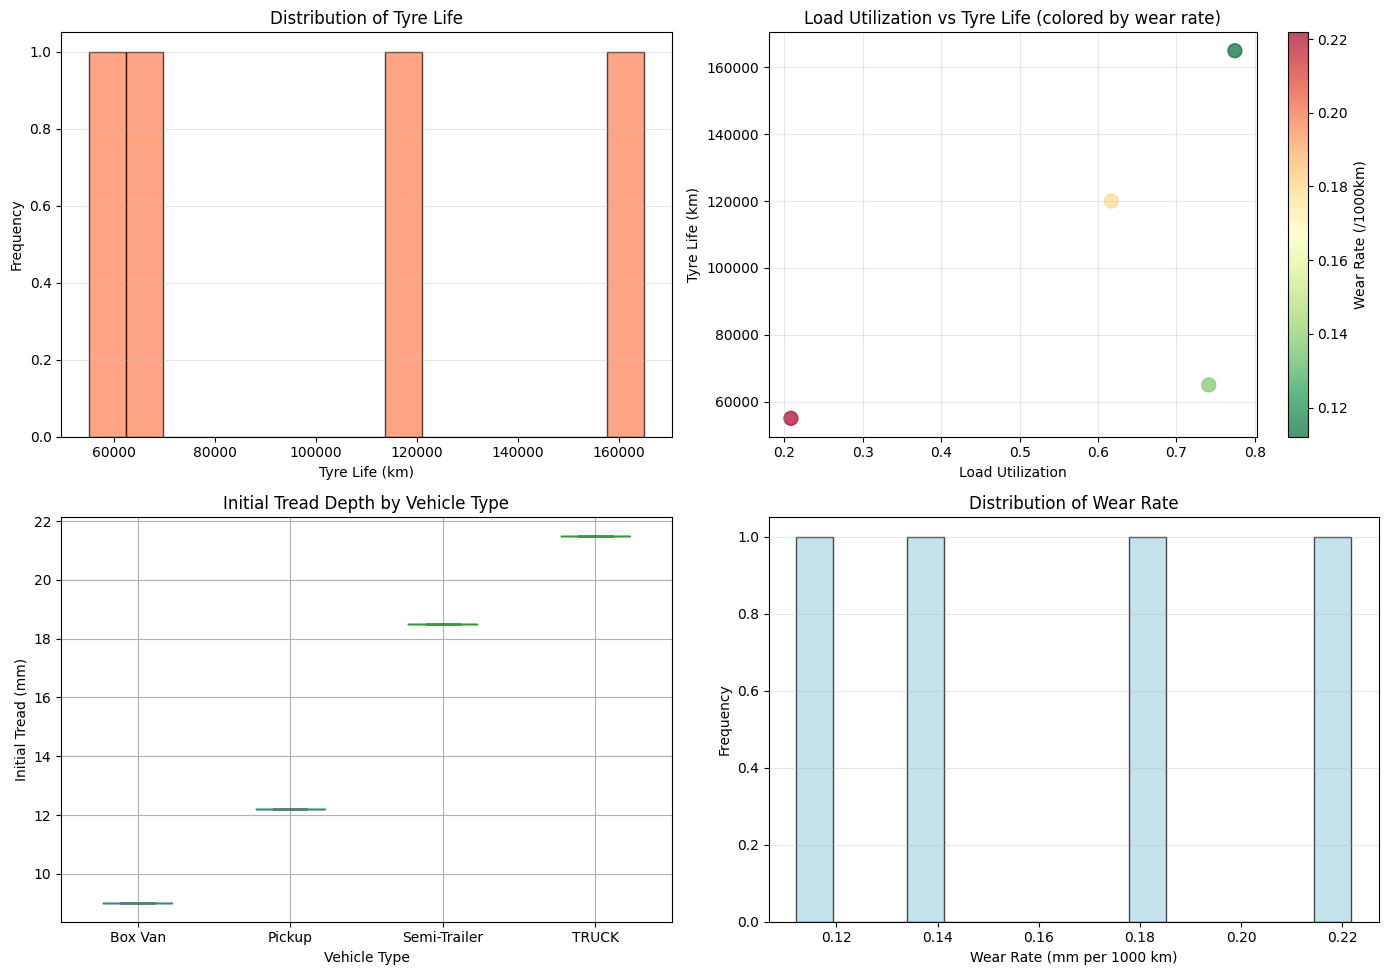



Correlation: Stress Metrics vs Wear:
                      wear_rate_per_1000km  tyre_life_km
load_utilization                 -0.936938      0.611082
driven_ratio                     -0.933013      0.876849
load_per_wheel                   -0.721296      0.963232
wear_rate_per_1000km              1.000000     -0.646971
tyre_life_km                     -0.646971      1.000000


In [33]:
# Extract tyre life in km (handle both string and numeric formats)
if df['tyre_life'].dtype == 'object':
    df['tyre_life_km'] = df['tyre_life'].str.replace(' km', '').astype(float)
else:
    df['tyre_life_km'] = df['tyre_life'].astype(float)

# Extract initial tread (handle both string and numeric formats)
if df['initial_tread'].dtype == 'object':
    df['initial_tread_mm'] = df['initial_tread'].str.replace('mm', '').str.replace(' ', '').astype(float)
else:
    df['initial_tread_mm'] = df['initial_tread'].astype(float)

# Calculate wear rate: tread depth per 1000 km
df['wear_rate_per_1000km'] = (df['initial_tread_mm'] / (df['tyre_life_km'] / 1000)).fillna(0)

print("Wear Behavior Statistics:")
print(df[['initial_tread_mm', 'tyre_life_km', 'wear_rate_per_1000km']].describe())

print("\n" + "="*60)
print("\nWear Metrics by Vehicle Type:")
wear_by_type = df.groupby('vehicle_type').agg({
    'initial_tread_mm': ['mean', 'min', 'max'],
    'tyre_life_km': ['mean', 'min', 'max'],
    'wear_rate_per_1000km': ['mean', 'std']
}).round(2)
print(wear_by_type)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tyre Life Distribution
axes[0, 0].hist(df['tyre_life_km'], bins=15, edgecolor='black', alpha=0.7, color='coral')
axes[0, 0].set_xlabel('Tyre Life (km)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Tyre Life')
axes[0, 0].grid(axis='y', alpha=0.3)

# Load Utilization vs Tyre Life (scatter)
scatter = axes[0, 1].scatter(df['load_utilization'], df['tyre_life_km'], 
                             c=df['wear_rate_per_1000km'], cmap='RdYlGn_r', s=100, alpha=0.7)
axes[0, 1].set_xlabel('Load Utilization')
axes[0, 1].set_ylabel('Tyre Life (km)')
axes[0, 1].set_title('Load Utilization vs Tyre Life (colored by wear rate)')
axes[0, 1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0, 1], label='Wear Rate (/1000km)')

# Initial Tread by Vehicle Type
df.boxplot(column='initial_tread_mm', by='vehicle_type', ax=axes[1, 0])
axes[1, 0].set_xlabel('Vehicle Type')
axes[1, 0].set_ylabel('Initial Tread (mm)')
axes[1, 0].set_title('Initial Tread Depth by Vehicle Type')
plt.suptitle('')

# Wear Rate Distribution
axes[1, 1].hist(df['wear_rate_per_1000km'], bins=15, edgecolor='black', alpha=0.7, color='lightblue')
axes[1, 1].set_xlabel('Wear Rate (mm per 1000 km)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Wear Rate')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation with stress metrics
print("\n" + "="*60)
print("\nCorrelation: Stress Metrics vs Wear:")
corr_cols = ['load_utilization', 'driven_ratio', 'load_per_wheel', 'wear_rate_per_1000km', 'tyre_life_km']
correlation_matrix = df[corr_cols].corr()
print(correlation_matrix[['wear_rate_per_1000km', 'tyre_life_km']])


## 3. Wear Behavior Analysis

Tyre life, initial tread depth, and wear rate reflect how stress translates to actual wear.


In [ ]:
# Analyze driven ratio
print("Driven Ratio Statistics:")
print(df['driven_ratio'].describe())

print("\n" + "="*60)
print("\nDriven Ratio Distribution:")
print(df['driven_ratio'].value_counts().sort_index())

print("\n" + "="*60)
print("\nStress Impact by Driven Ratio:")
ratio_analysis = df.groupby('driven_ratio').agg({
    'vehicle_category': 'count',
    'load_per_wheel': ['mean', 'std'],
    'load_utilization': ['mean', 'std'],
    'initial_tread': 'mean',
    'tyre_life': 'mean'
}).round(3)
ratio_analysis.columns = ['Count','Load Per Wheel Mean','Load Per Wheel Std','Load Util Mean','Load Util Std','Initial Tread Mean','Tyre Life Mean']
print(ratio_analysis)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter: Driven Ratio vs Load Per Wheel
axes[0, 0].scatter(df['driven_ratio'], df['load_per_wheel'], alpha=0.6, s=100, c=df['load_utilization'], cmap='YlOrRd')
axes[0, 0].set_xlabel('Driven Ratio')
axes[0, 0].set_ylabel('Load Per Wheel')
axes[0, 0].set_title('Driven Ratio vs Load Per Wheel (colored by utilization)')
axes[0, 0].grid(alpha=0.3)

# Scatter: Driven Ratio vs Initial Tread
axes[0, 1].scatter(df['driven_ratio'], df['initial_tread'], alpha=0.6, s=100, c='green')
axes[0, 1].set_xlabel('Driven Ratio')
axes[0, 1].set_ylabel('Initial Tread (mm)')
axes[0, 1].set_title('Driven Ratio vs Initial Tread')
axes[0, 1].grid(alpha=0.3)

# Bar: Count by Driven Ratio
df['driven_ratio'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Driven Ratio')
axes[1, 0].set_ylabel('Vehicle Count')
axes[1, 0].set_title('Vehicle Count by Driven Ratio')
axes[1, 0].grid(axis='y', alpha=0.3)

# Box plot: Load Utilization by Driven Ratio
df.boxplot(column='load_utilization', by='driven_ratio', ax=axes[1, 1])
axes[1, 1].set_xlabel('Driven Ratio')
axes[1, 1].set_ylabel('Load Utilization')
axes[1, 1].set_title('Load Utilization Distribution by Driven Ratio')
plt.suptitle('')

plt.tight_layout()
plt.show()


## 2. Driven Ratio Analysis

Driven ratio = driven_wheels / total_wheels
Lower ratio = fewer wheels sharing the load = higher stress per wheel


Load Utilization Statistics:
count    4.000000
mean     0.585345
std      0.260335
min      0.208333
25%      0.514849
50%      0.679200
75%      0.749696
max      0.774648
Name: load_utilization, dtype: float64

Vehicles with high utilization (>0.8): 0
Vehicles with extreme utilization (>1.0): 0


Load Utilization by Vehicle Type:
              count      mean       min       max  std
vehicle_type                                          
Box Van           1  0.741379  0.741379  0.741379  NaN
Pickup            1  0.208333  0.208333  0.208333  NaN
Semi-Trailer      1  0.774648  0.774648  0.774648  NaN
TRUCK             1  0.617021  0.617021  0.617021  NaN


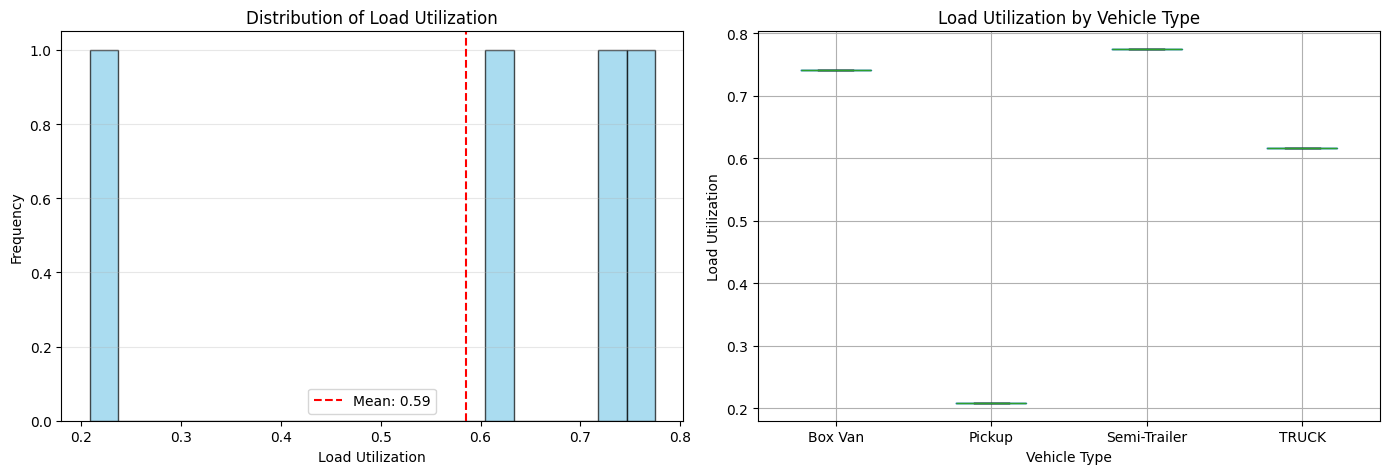

In [31]:
# Compute load utilization: actual load per wheel / max load per wheel
df['load_utilization'] = df['load_per_wheel'] / df['max_load_single_kg']

# Summary statistics
print("Load Utilization Statistics:")
print(df['load_utilization'].describe())
print(f"\nVehicles with high utilization (>0.8): {(df['load_utilization'] > 0.8).sum()}")
print(f"Vehicles with extreme utilization (>1.0): {(df['load_utilization'] > 1.0).sum()}")

# Distribution by vehicle type
print("\n" + "="*60)
print("\nLoad Utilization by Vehicle Type:")
print(df.groupby('vehicle_type')['load_utilization'].agg(['count', 'mean', 'min', 'max', 'std']))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['load_utilization'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(df['load_utilization'].mean(), color='red', linestyle='--', label=f'Mean: {df["load_utilization"].mean():.2f}')
axes[0].set_xlabel('Load Utilization')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Load Utilization')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot by vehicle type
df.boxplot(column='load_utilization', by='vehicle_type', ax=axes[1])
axes[1].set_xlabel('Vehicle Type')
axes[1].set_ylabel('Load Utilization')
axes[1].set_title('Load Utilization by Vehicle Type')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()


## 1. Load Utilization Analysis

Load utilization reflects how much weight each wheel carries relative to its capacity.
High utilization = higher stress, faster wear.
